In [51]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Rescaling
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

In [33]:
def create_data_generators(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32):
    """
    Crea generadores de datos con augmentation dinámica solo para el conjunto de entrenamiento
    """
    print(f"Creando generadores de datos con batch_size={batch_size}")
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8,1.2],
        fill_mode='nearest'
    )
    
    # Generadores para validación y test - solo normalización
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Crear los generadores
    train_generator = train_datagen.flow(
        X_train, y_train,
        batch_size=batch_size,
        shuffle=True
    )
    
    val_generator = val_test_datagen.flow(
        X_val, y_val,
        batch_size=batch_size,
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow(
        X_test, y_test,
        batch_size=batch_size,
        shuffle=False
    )
    
    return train_generator, val_generator, test_generator


In [34]:
def preprocess_pipeline(data_dir, img_size=(224, 224), batch_size=32):
    """Pipeline completo de preprocesamiento de datos"""
        
    print(f"\nIniciando pipeline de preprocesamiento...")
    print(f"Directorio de datos: {data_dir}")
    print(f"Tamaño de imagen: {img_size}")
    print(f"Batch size: {batch_size}\n")

    # Cargar datos sin normalizar (la normalización se hará en los generadores)
    X, y, classes = load_and_preprocess_data(data_dir, img_size, normalize=False)
    
    # Convertir etiquetas a one-hot encoding
    y = to_categorical(y, num_classes=len(classes))
    
    # Dividir dataset
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.3,  # 30% para val+test
        random_state=42,
        stratify=y
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.33,  # 10% del total para test
        random_state=42,
        stratify=y_temp
    )
    
    print(f"División de datos:")
    print(f"- Train: {X_train.shape[0]} muestras")
    print(f"- Validación: {X_val.shape[0]} muestras")
    print(f"- Test: {X_test.shape[0]} muestras")
    
    # Crear generadores
    train_generator, val_generator, test_generator = create_data_generators(
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        batch_size
    )
    
    print("\nPipeline de preprocesamiento completado con éxito!")

    return {
        'train_generator': train_generator,
        'val_generator': val_generator,
        'test_generator': test_generator,
        'classes': classes
    }

In [35]:
def load_and_preprocess_data(data_dir, img_size=(224, 224), normalize=False):
    """Carga y preprocesa imágenes desde el directorio de datos"""
    if not os.path.exists(data_dir):
        raise ValueError(f"El directorio {data_dir} no existe")
        
    X = []
    y = []
    
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    if not classes:
        raise ValueError(f"No se encontraron subdirectorios (clases) en {data_dir}")
    
    class_indices = {cls: i for i, cls in enumerate(classes)}
    
    print(f"Encontradas {len(classes)} clases: {classes}")
    
    total_images = 0
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        class_idx = class_indices[class_name]
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        print(f"Procesando clase '{class_name}': {len(image_files)} imágenes encontradas")
        
        for img_file in image_files:
            img_path = os.path.join(class_dir, img_file)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Error: No se pudo cargar la imagen {img_path}")
                    continue
                
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                
                X.append(img)
                y.append(class_idx)
                total_images += 1

            except Exception as e:
                print(f"Error procesando {img_path}: {str(e)}")
    
    if total_images == 0:
        raise ValueError("No se pudieron cargar imágenes del directorio")
        
    print(f"Total de imágenes cargadas: {total_images}")
    
    X = np.array(X)
    y = np.array(y)

    print(f"Forma del array X: {X.shape}")
    print(f"Forma del array y: {y.shape}")
    
    if normalize:
        X = X.astype('float32') / 255.0
    
    return X, y, classes


In [36]:
data_dir = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary"
generators = preprocess_pipeline(data_dir, img_size=(224, 224), batch_size=32)


Iniciando pipeline de preprocesamiento...
Directorio de datos: /Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary
Tamaño de imagen: (224, 224)
Batch size: 32

Encontradas 19 clases: ['R', 'U', 'I', 'N', 'G', 'T', 'S', 'A', 'F', 'O', 'M', 'C', 'D', 'Q', 'E', 'B', 'K', 'L', 'P']
Procesando clase 'R': 90 imágenes encontradas
Procesando clase 'U': 108 imágenes encontradas
Procesando clase 'I': 113 imágenes encontradas
Procesando clase 'N': 111 imágenes encontradas
Procesando clase 'G': 108 imágenes encontradas
Procesando clase 'T': 102 imágenes encontradas
Procesando clase 'S': 100 imágenes encontradas
Procesando clase 'A': 102 imágenes encontradas
Procesando clase 'F': 105 imágenes encontradas
Procesando clase 'O': 97 imágenes encontradas
Procesando clase 'M': 114 imágenes encontradas
Procesando clase 'C': 98 imágenes encontradas
Procesando clase 'D': 102 imágenes encontradas
Procesando clase 'Q': 120 imágenes encontradas
Procesando clase 'E':

## Para usar el código en el entrenamiento

In [39]:
def create_model(input_shape, num_classes):
    """
    Crea un modelo CNN para clasificación de señas
    """
    model = Sequential([
        # Primera capa convolucional
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),
        
        # Segunda capa convolucional
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Tercera capa convolucional
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Aplanar
        Flatten(),
        
        # Capas densas
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    # Compilar el modelo
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [38]:
img_size = (224, 224)
batch_size = 32
epochs = 50

In [40]:
generators = preprocess_pipeline(data_dir, img_size=img_size, batch_size=batch_size)
    
    
input_shape = (img_size[0], img_size[1], 3)  # (224, 224, 3)
num_classes = len(generators['classes'])
model = create_model(input_shape, num_classes)
    


Iniciando pipeline de preprocesamiento...
Directorio de datos: /Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary
Tamaño de imagen: (224, 224)
Batch size: 32

Encontradas 19 clases: ['R', 'U', 'I', 'N', 'G', 'T', 'S', 'A', 'F', 'O', 'M', 'C', 'D', 'Q', 'E', 'B', 'K', 'L', 'P']
Procesando clase 'R': 90 imágenes encontradas
Procesando clase 'U': 108 imágenes encontradas
Procesando clase 'I': 113 imágenes encontradas
Procesando clase 'N': 111 imágenes encontradas
Procesando clase 'G': 108 imágenes encontradas
Procesando clase 'T': 102 imágenes encontradas
Procesando clase 'S': 100 imágenes encontradas
Procesando clase 'A': 102 imágenes encontradas
Procesando clase 'F': 105 imágenes encontradas
Procesando clase 'O': 97 imágenes encontradas
Procesando clase 'M': 114 imágenes encontradas
Procesando clase 'C': 98 imágenes encontradas
Procesando clase 'D': 102 imágenes encontradas
Procesando clase 'Q': 120 imágenes encontradas
Procesando clase 'E':

/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,596,691 (21.35 MB)

 Trainable params: 5,596,691 (21.35 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    generators['train_generator'],
    validation_data=generators['val_generator'],
    epochs=epochs,
    steps_per_epoch=len(generators['train_generator']),
    validation_steps=len(generators['val_generator']))
    
test_loss, test_accuracy = model.evaluate(generators['test_generator'])
print(f"\nPrecisión en el conjunto de prueba: {test_accuracy*100:.2f}%")
    

/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 488ms/step - accuracy: 0.0577 - loss: 2.9520 - val_accuracy: 0.0597 - val_loss: 2.9427
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 502ms/step - accuracy: 0.0751 - loss: 2.9380 - val_accuracy: 0.1617 - val_loss: 2.8035
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 482ms/step - accuracy: 0.1012 - loss: 2.7986 - val_accuracy: 0.1915 - val_loss: 2.5524
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 475ms/step - accuracy: 0.1158 - loss: 2.7484 - val_accuracy: 0.2736 - val_loss: 2.3771
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.1579 - loss: 2.5523 - val_accuracy: 0.2985 - val_loss: 2.1115
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - accuracy: 0.1637 - loss: 2.4173 - val_accuracy: 0.3060 - val_loss: 2.0453
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - accuracy: 0.1832 - loss: 2.3704 - val_accuracy: 0.2811 - val_loss: 2.0674
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 482ms/step - accuracy: 0.2235 - loss: 2.2869 - val_accu

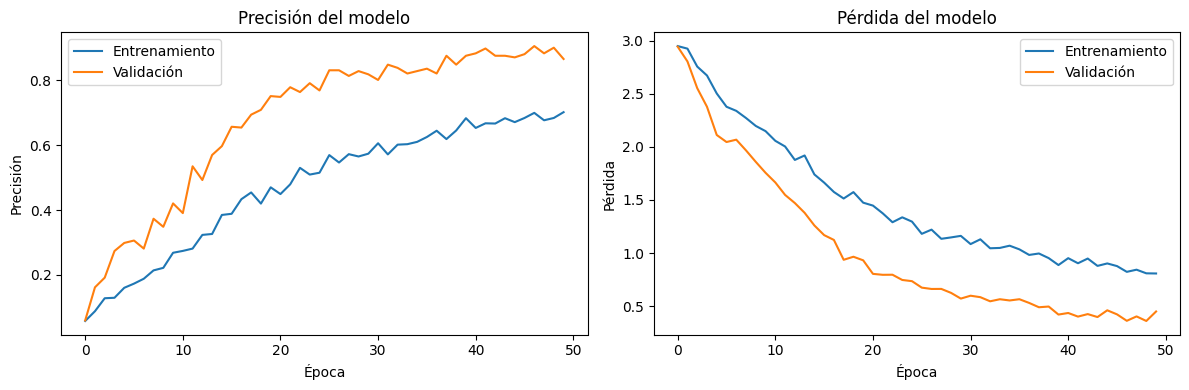

In [43]:
plt.figure(figsize=(12, 4))
    
# Gráfico de precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# MobileNetV2

In [52]:
def load_and_preprocess_data(data_dir, img_size=(224, 224)):
    """Carga datos desde el directorio"""
    X = []
    y = []
    
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    if not classes:
        raise ValueError(f"No se encontraron subdirectorios (clases) en {data_dir}")
    
    class_indices = {cls: i for i, cls in enumerate(classes)}
    
    print(f"Encontradas {len(classes)} clases: {classes}")
    
    total_images = 0
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        class_idx = class_indices[class_name]
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        print(f"Procesando clase '{class_name}': {len(image_files)} imágenes encontradas")
        
        for img_file in image_files:
            img_path = os.path.join(class_dir, img_file)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Error: No se pudo cargar la imagen {img_path}")
                    continue
                
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                
                X.append(img)
                y.append(class_idx)
                total_images += 1

            except Exception as e:
                print(f"Error procesando {img_path}: {str(e)}")
    
    if total_images == 0:
        raise ValueError("No se pudieron cargar imágenes del directorio")
        
    print(f"Total de imágenes cargadas: {total_images}")
    
    X = np.array(X)
    y = np.array(y)

    print(f"Forma del array X: {X.shape}")
    print(f"Forma del array y: {y.shape}")
    
    return X, y, classes


In [53]:
def data_augmentation():
    """Creación de capas de data augmentation"""
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomTranslation(0.2, 0.2),
        tf.keras.layers.RandomContrast(0.2),
    ])

In [54]:
def create_datasets(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32):
    """Crea tf.data.Dataset con augmentation y optimización"""
    
    # Convertir etiquetas a one-hot
    num_classes = y_train.shape[1]
    
    # Crear datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    
    # Función para procesar datos de entrenamiento
    def process_train_data(image, label):
        image = tf.cast(image, tf.float32)
        # Data augmentation solo en entrenamiento
        image = data_augmentation()(image)
        # Preprocesamiento específico de MobileNetV2
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
        return image, label
    
    # Función para procesar datos de validación/test
    def process_val_test_data(image, label):
        image = tf.cast(image, tf.float32)
        # Solo preprocesamiento
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
        return image, label
    
    # Aplicar transformaciones y optimizar datasets
    train_ds = train_ds.map(process_train_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    val_ds = val_ds.map(process_val_test_data, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    test_ds = test_ds.map(process_val_test_data, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds, test_ds

In [55]:
def create_model(input_shape, num_classes):
    """Crea un modelo basado en MobileNetV2 con transfer learning"""
    # Cargar MobileNetV2 pre-entrenado
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Congelar el modelo base
    base_model.trainable = False
    
    # Crear el modelo completo
    inputs = tf.keras.Input(shape=input_shape)
    
    # Pasar los datos a través del modelo base
    x = base_model(inputs, training=False)
    
    # Pooling global
    x = GlobalAveragePooling2D()(x)
    
    # Capas de clasificación
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    # Compilar el modelo
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

In [56]:
def preprocess_pipeline(data_dir, img_size=(224, 224), batch_size=32):
    """Pipeline completo de preprocesamiento de datos"""
    print(f"\nIniciando pipeline de preprocesamiento...")
    print(f"Directorio de datos: {data_dir}")
    print(f"Tamaño de imagen: {img_size}")
    print(f"Batch size: {batch_size}\n")

    # Cargar datos
    X, y, classes = load_and_preprocess_data(data_dir, img_size)
    
    # Convertir etiquetas a one-hot encoding
    y_one_hot = tf.keras.utils.to_categorical(y, num_classes=len(classes))
    
    # Dividir dataset
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_one_hot,
        test_size=0.3,  # 30% para val+test
        random_state=42,
        stratify=y
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.33,  # 10% del total para test
        random_state=42,
        stratify=y_temp
    )
    
    print(f"División de datos:")
    print(f"- Train: {X_train.shape[0]} muestras")
    print(f"- Validación: {X_val.shape[0]} muestras")
    print(f"- Test: {X_test.shape[0]} muestras")
    
    # Crear datasets optimizados
    train_ds, val_ds, test_ds = create_datasets(
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        batch_size
    )
    
    print("\nPipeline de preprocesamiento completado con éxito!")

    return {
        'train_ds': train_ds,
        'val_ds': val_ds,
        'test_ds': test_ds,
        'classes': classes,
        'steps_per_epoch': len(X_train) // batch_size,
        'validation_steps': len(X_val) // batch_size
    }

In [ ]:
data_dir = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary"
img_size = (224, 224)
batch_size = 32
initial_epochs = 10
fine_tuning_epochs = 10
        
        # Obtener los datasets y preprocesar datos
data = preprocess_pipeline(data_dir, img_size=img_size, batch_size=batch_size)
        
        # Crear el modelo
input_shape = (img_size[0], img_size[1], 3)
num_classes = len(data['classes'])
model, base_model = create_model(input_shape, num_classes)
        
        # Mostrar el resumen del modelo
model.summary()
        
print("Entrenamiento inicial con base model congelado...")
        # Entrenar el modelo con la base congelada
history = model.fit(
    data['train_ds'],
    validation_data=data['val_ds'],
    epochs=initial_epochs,
    steps_per_epoch=data['steps_per_epoch'],
    validation_steps=data['validation_steps']
    )


Iniciando pipeline de preprocesamiento...
Directorio de datos: /Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary
Tamaño de imagen: (224, 224)
Batch size: 32

Encontradas 19 clases: ['R', 'U', 'I', 'N', 'G', 'T', 'S', 'A', 'F', 'O', 'M', 'C', 'D', 'Q', 'E', 'B', 'K', 'L', 'P']
Procesando clase 'R': 90 imágenes encontradas
Procesando clase 'U': 108 imágenes encontradas
Procesando clase 'I': 113 imágenes encontradas
Procesando clase 'N': 111 imágenes encontradas
Procesando clase 'G': 108 imágenes encontradas
Procesando clase 'T': 102 imágenes encontradas
Procesando clase 'S': 100 imágenes encontradas
Procesando clase 'A': 102 imágenes encontradas
Procesando clase 'F': 105 imágenes encontradas
Procesando clase 'O': 97 imágenes encontradas


In [ ]:
print("Fine-tuning del modelo...")
    # Descongelar el modelo base para fine-tuning
base_model.trainable = True
    
    # Congelar las primeras capas
for layer in base_model.layers[:100]:
    layer.trainable = False
    
    # Recompilar el modelo con una tasa de aprendizaje más baja
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
    
    # Fine-tuning
fine_tuning_history = model.fit(
    data['train_ds'],
    validation_data=data['val_ds'],
    epochs=initial_epochs + fine_tuning_epochs,
    initial_epoch=initial_epochs,
    steps_per_epoch=data['steps_per_epoch'],
    validation_steps=data['validation_steps']
)
    

In [ ]:
test_results = model.evaluate(data['test_ds'])
test_loss, test_accuracy = test_results
print(f"\nPrecisión en el conjunto de prueba: {test_accuracy*100:.2f}%")
    
    # Combinar historiales
acc = history.history['accuracy'] + fine_tuning_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tuning_history.history['val_accuracy']
loss = history.history['loss'] + fine_tuning_history.history['loss']
val_loss = history.history['val_loss'] + fine_tuning_history.history['val_loss']    

In [ ]:
plt.figure(figsize=(12, 4))

# Gráfico de precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento')
plt.plot(val_acc, label='Validación')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Inicio Fine Tuning')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento')
plt.plot(val_loss, label='Validación')
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Inicio Fine Tuning')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()